# Replication
## Goal of this project: 
Produce a replication of the work of: *Iacobucci, I., Zeng, A.G.X., Gao, Q. et al. Multipotent lineage potential in B cell acute lymphoblastic leukemia is associated with distinct cellular origins and clinical features. Nat Cancer 6, 1242–1262 (2025). https://doi.org/10.1038/s43018-025-00987-2*
Sample SCPCS000358
C:\Users\sambe\Documents\bigdata\High-Hyperdiploid\SCPCS000358

##Steps:
1. Download relevant libraries into pixi or conda environment.
2. Load relevant Anndata into my kernal.
3. View and think about this piece of data and its paramenters.
4. QC the data and clean it.
5. Normalise the dataset
6. Identify highly variable genes (feature selection)
7. Dimensional reduction of data (PCA and UMAP)
8. Observe the UMAP and its appearance, try and find batch effects. (If batch effects present determine a batch correction tool for use.)
9. Cluster with Leiden algorithm 
10. Annotate clusters, using Celltypist or Professional opinion. Long step requires lots of knowledge.
11. Repeat data integration and try and find more batch effects. 
12. Repeat and loop back if necessary to identify interesting phenomenom.

Environment setup:
Created conda environment "sc-rep"
>conda install -c conda-forge scanpy pandas numpy ipykernel
Within Visual Studio Code Jupyter Notebook set sc-rep as Kernal
>conda install -c conda-forge seaborn

Hosted on WSL inside VisualStudioCode IDE.

## Loading Data

In [1]:
#Importing relevant libraries
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import anndata
from scipy.stats import median_abs_deviation

import os
print(os.getcwd())
sc.settings.figdir = "../output/plots"

/home/lizalfos/sc-explorations/scripts


In [2]:
anndata = sc.read_h5ad("/home/lizalfos/sc-explorations/data/high-hyperdiploid/SCPCS000358/SCPCL000629_unfiltered_rna.h5ad")
print(anndata)
# alternative path /mnt/c/Users/sambe/Documents/bigdata/High-Hyperdiploid/SCPCS000358/

AnnData object with n_obs × n_vars = 183325 × 60319
    obs: 'barcodes', 'sum', 'detected', 'subsets_mito_sum', 'subsets_mito_detected', 'subsets_mito_percent', 'total', 'library_id', 'sample_id', 'scpca_project_id', 'submitter_id', 'participant_id', 'submitter', 'age', 'age_timing', 'sex', 'diagnosis', 'subdiagnosis', 'tissue_location', 'disease_timing', 'organism', 'is_xenograft', 'is_cell_line', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'organism_ontology_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'is_primary_data'
    var: 'gene_ids', 'gene_symbol', 'mean', 'detected', 'feature_is_filtered'
    uns: 'X_name', 'af_num_cells', 'af_permit_type', 'af_resolution', 'alevinfry_version', 'assay_ontology_term_id', 'include_unspliced', 'library_id', 'mapped_reads', 'mapping_tool', 'project_id', 'reference_index', 'salmon_version', 'sample_id', 'sample_type', 'schema_v

## Quality Control

### Filtering low quality cells

In [3]:
# View the data and get a feel for its shape
#print(anndata.obs.head()) #Observervations (cells)
#print(anndata.var.head()) #Variables (genes)
#print(anndata.X) #Expression matrix
#print(anndata.var["feature_is_filtered"].unique())

In [4]:
# Add metadata columns for quality control
# mitochondrial genes
anndata.var["mt"] = anndata.var_names.str.startswith("MT-")
# ribosomal genes
anndata.var["ribo"] = anndata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
anndata.var["hb"] = anndata.var_names.str.contains("^HB[^(P)]")

In [5]:
help(sc.pp.calculate_qc_metrics)

Help on function calculate_qc_metrics in module scanpy.preprocessing._qc:

calculate_qc_metrics(
    adata: 'AnnData',
    *,
    expr_type: 'str' = 'counts',
    var_type: 'str' = 'genes',
    qc_vars: 'Collection[str] | str' = (),
    percent_top: 'Collection[int] | None' = (50, 100, 200, 500),
    layer: 'str | None' = None,
    use_raw: 'bool' = False,
    inplace: 'bool' = False,
    log1p: 'bool' = True,
    parallel: 'bool | None' = None
) -> 'tuple[pd.DataFrame, pd.DataFrame] | None'
    Calculate quality control metrics.

    Calculates a number of qc metrics for an AnnData object, see section
    `Returns` for specifics. Largely based on `calculateQCMetrics` from scater
    :cite:p:`McCarthy2017`. Currently is most efficient on a sparse CSR or dense matrix.

    Note that this method can take a while to compile on the first call. That
    result is then cached to disk to be used later.

    Parameters
    ----------
    adata
        Annotated data matrix.
    expr_type
     

In [6]:
anndata.var["mt"].unique()

array([False])

In [7]:
sc.pp.calculate_qc_metrics(
    anndata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
anndata

AnnData object with n_obs × n_vars = 183325 × 60319
    obs: 'barcodes', 'sum', 'detected', 'subsets_mito_sum', 'subsets_mito_detected', 'subsets_mito_percent', 'total', 'library_id', 'sample_id', 'scpca_project_id', 'submitter_id', 'participant_id', 'submitter', 'age', 'age_timing', 'sex', 'diagnosis', 'subdiagnosis', 'tissue_location', 'disease_timing', 'organism', 'is_xenograft', 'is_cell_line', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'organism_ontology_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'is_primary_data', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'gene_symbol', 'mean', '

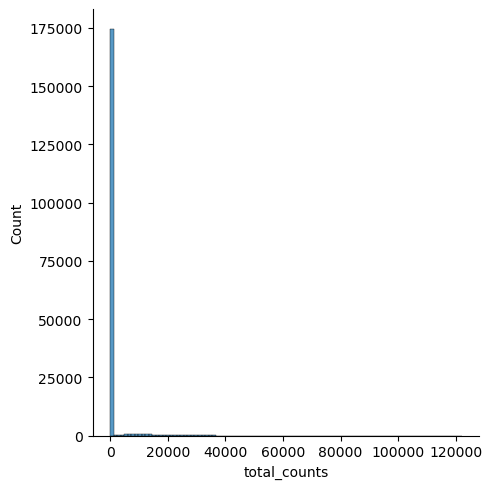

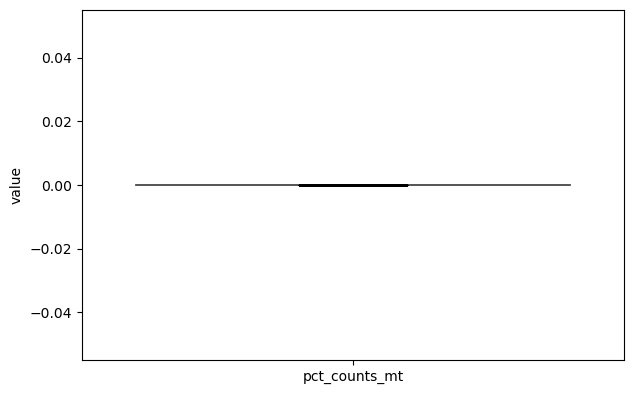

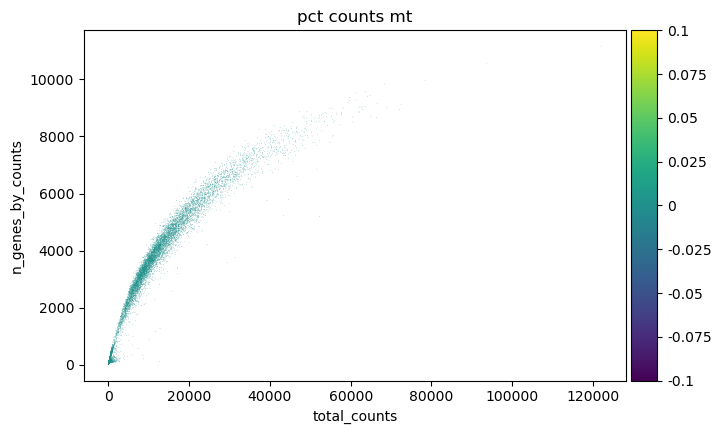

In [8]:
p1 = sns.displot(anndata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(anndata, 'total_counts')
p2 = sc.pl.violin(anndata, "pct_counts_mt")
p3 = sc.pl.scatter(anndata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### MAD (median absolute deviations)
A robust method of identifying outliers compared to Variance or Standard Deviation. This is due to it being less impacted by extreme values and non-normality of data. Especially useful in case of non-normal data. 

MAD = median(|Yi – median(Y)|)
Take median of data -> remove this from a set value of MAD used in your analysis(Yi), such as 5 MAD -> pass it through as an absolute value* -> Take the median of distances. producing the MAD.


* The "|" represent this. An absolute value is a numbers distance from zero, ignoring positive or negative.


In [9]:
def is_outlier(anndata, metric: str, nmads: int):
    M = anndata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [10]:
anndata.obs["outlier"] = (
    is_outlier(anndata, "log1p_total_counts", 5)
    | is_outlier(anndata, "log1p_n_genes_by_counts", 5)
    | is_outlier(anndata, "pct_counts_in_top_20_genes", 5)
)
anndata.obs.outlier.value_counts()

outlier
False    159005
True      24320
Name: count, dtype: int64

In [11]:
anndata.obs["mt_outlier"] = is_outlier(anndata, "pct_counts_mt", 3) | (
    anndata.obs["pct_counts_mt"] > 8
)
anndata.obs.mt_outlier.value_counts()

mt_outlier
False    183325
Name: count, dtype: int64

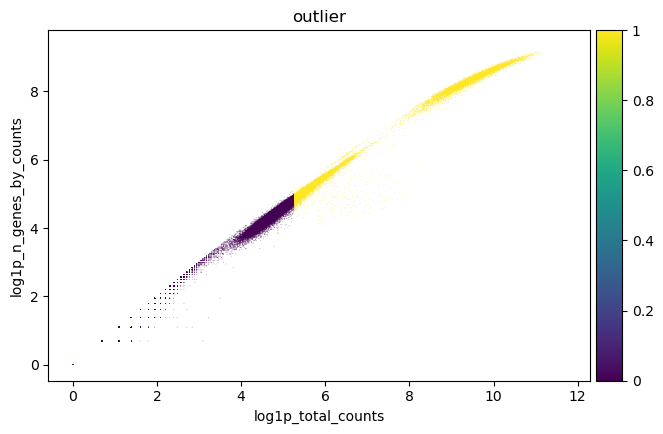

<Axes: xlabel='log1p_total_counts', ylabel='log1p_n_genes_by_counts'>

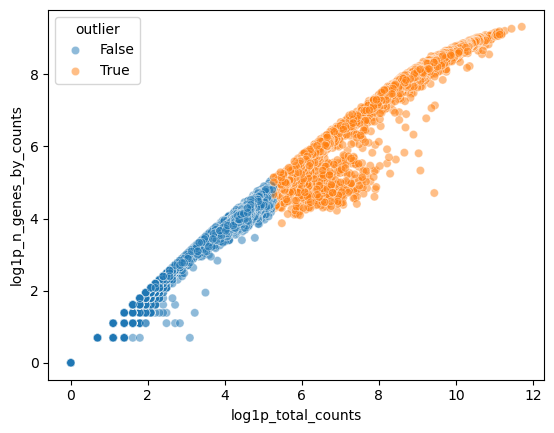

In [12]:
anndata.obs
sc.pl.scatter(anndata, "log1p_total_counts", "log1p_n_genes_by_counts", color="outlier")
sns.scatterplot(
    data=anndata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    hue="outlier",
    alpha=0.5,
)
# Following the sc best practices practice method removes 24320 cells from the dataset, this doesn't appear to be right for this particular dataset, I will keep going then make a different pipeline following the method the authors to see the difference next.

In [13]:
    print(f"Total number of cells: {anndata.n_obs}")
    anndata = anndata[(~anndata.obs.outlier) & (~anndata.obs.mt_outlier)].copy()

    print(f"Number of cells after filtering of low quality cells: {anndata.n_obs}")

Total number of cells: 183325
Number of cells after filtering of low quality cells: 159005


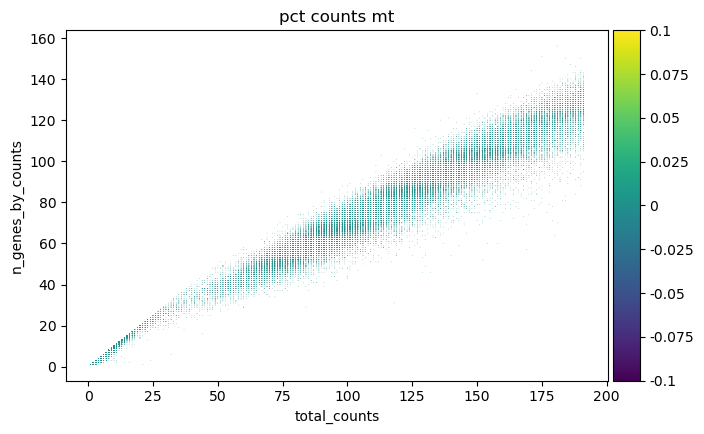

In [14]:
p1 = sc.pl.scatter(anndata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### Correction of ambient RNA

In [15]:
# nothing here

### Doublet Detection

In [16]:
anndata.layers['spliced']

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 4458043 stored elements and shape (159005, 60319)>

## Normalization

In [17]:
# sc.pp.log1p(anndata)
# Normalize the data using scran-like normalization and store in a layer
anndata.layers['scran_normalization'] = anndata.X.copy()  # Copy raw X to the layer
sc.pp.normalize_total(anndata, target_sum=1e4, layer="scran_normalization")
sc.pp.log1p(anndata, layer="scran_normalization")

/home/lizalfos/miniconda3/envs/sc-rep/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


## Feature selection

In [18]:

sc.pp.highly_variable_genes(anndata,layer="scran_normalization", flavor="seurat", n_top_genes=2000)
anndata
# To improve flavor to seurat_v3, would need to install scikit-misc.

AnnData object with n_obs × n_vars = 159005 × 60319
    obs: 'barcodes', 'sum', 'detected', 'subsets_mito_sum', 'subsets_mito_detected', 'subsets_mito_percent', 'total', 'library_id', 'sample_id', 'scpca_project_id', 'submitter_id', 'participant_id', 'submitter', 'age', 'age_timing', 'sex', 'diagnosis', 'subdiagnosis', 'tissue_location', 'disease_timing', 'organism', 'is_xenograft', 'is_cell_line', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'organism_ontology_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'is_primary_data', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_ids',

## Dimensionality Reduction

In [19]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
# anndata.var["highly_variable"] = anndata.var["highly_deviant"]
sc.pp.pca(anndata, svd_solver="arpack", mask_var="highly_variable")

In [31]:
anndata

AnnData object with n_obs × n_vars = 159005 × 60319
    obs: 'barcodes', 'sum', 'detected', 'subsets_mito_sum', 'subsets_mito_detected', 'subsets_mito_percent', 'total', 'library_id', 'sample_id', 'scpca_project_id', 'submitter_id', 'participant_id', 'submitter', 'age', 'age_timing', 'sex', 'diagnosis', 'subdiagnosis', 'tissue_location', 'disease_timing', 'organism', 'is_xenograft', 'is_cell_line', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'organism_ontology_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'is_primary_data', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_ids',

In [33]:
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

/home/lizalfos/miniconda3/envs/sc-rep/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lizalfos/miniconda3/envs/sc-rep/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/lizalfos/miniconda3/envs/sc-rep/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/lizalfos/miniconda3/envs/sc-rep/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral

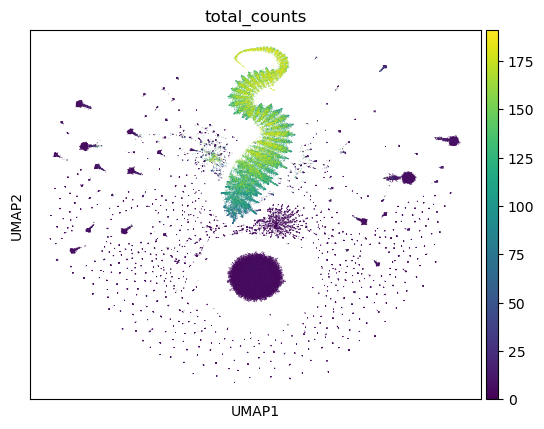

In [ ]:
sc.pl.umap(anndata, color="total_counts", save="_total_counts_030726.png")
